# Raw data ko ML model ke liye useful features (inputs) mein convert karna = Feature Engineering.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt


In [2]:
df = pd.read_csv('tested.csv')


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB


In [5]:
df['Survived'].isnull().sum()

np.int64(0)

In [9]:
df['Cabin'].isnull().sum()

np.int64(327)

In [10]:
df['Cabin'] = df['Cabin'].fillna(0)

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,0,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,0,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,0,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,0,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,0,S


In [13]:
print(df.shape)


(418, 12)


In [14]:
print(df.describe())


       PassengerId    Survived      Pclass         Age       SibSp  \
count   418.000000  418.000000  418.000000  332.000000  418.000000   
mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
std     120.810458    0.481622    0.841838   14.181209    0.896760   
min     892.000000    0.000000    1.000000    0.170000    0.000000   
25%     996.250000    0.000000    1.000000   21.000000    0.000000   
50%    1100.500000    0.000000    3.000000   27.000000    0.000000   
75%    1204.750000    1.000000    3.000000   39.000000    1.000000   
max    1309.000000    1.000000    3.000000   76.000000    8.000000   

            Parch        Fare  
count  418.000000  417.000000  
mean     0.392344   35.627188  
std      0.981429   55.907576  
min      0.000000    0.000000  
25%      0.000000    7.895800  
50%      0.000000   14.454200  
75%      0.000000   31.500000  
max      9.000000  512.329200  


In [15]:
print(df.describe(include=['O']))

                    Name   Sex    Ticket  Cabin Embarked
count                418   418       418    418      418
unique               418     2       363     77        3
top     Kelly, Mr. James  male  PC 17608      0        S
freq                   1   266         5    327      270


C:\Users\vinu\AppData\Local\Temp\ipykernel_9560\1303241096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['O']))


In [16]:
missing_data = df.isnull().sum().sort_values(ascending=False)
print(missing_data)

Age            86
Fare            1
PassengerId     0
Survived        0
Name            0
Pclass          0
SibSp           0
Sex             0
Parch           0
Ticket          0
Cabin           0
Embarked        0
dtype: int64


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin           0.000000
Embarked        0.000000
dtype: float64


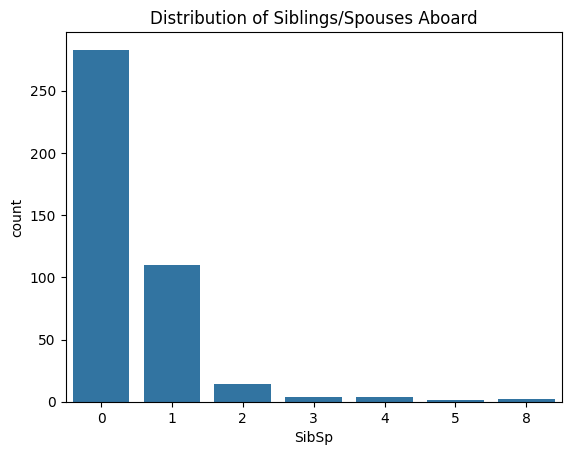

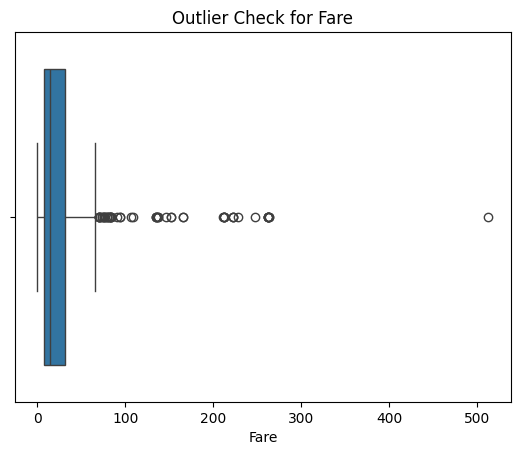

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of your target column (e.g., SibSp)
sns.countplot(data=df, x='SibSp')
plt.title('Distribution of Siblings/Spouses Aboard')
plt.show()

# Boxplot to easily check for outliers in numerical values like Fare
sns.boxplot(data=df, x='Fare')
plt.title('Outlier Check for Fare')
plt.show()